# 01 Data Cleaning

## Final Individual Project

**Project topic:** Screen Time and BMI Percentile among High School Students

**Research question:**  
Is there a linear relationship between screen time and BMI percentile among high school students?

This notebook prepares the data for a simple linear regression analysis.

The main variables are:

- **TelevisionWatching**: average school-day TV watching time
- **ComputerUse**: average school-day computer/video game use for non-school purposes
- **BMIPCT**: BMI percentile

Because the original screen time variables are categorical responses, they will be recoded into approximate numeric hours.


In [31]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)


In [32]:
# Project paths
project_dir = Path("..").resolve()

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"
summary_dir = project_dir / "outputs" / "summary"

# Create folders if they do not exist
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
summary_dir.mkdir(parents=True, exist_ok=True)

# Find raw data file
possible_files = [
    raw_dir / "YRBS_2007.csv",
    raw_dir / "YRBS_2007(2).csv",
    project_dir / "YRBS_2007.csv",
    project_dir / "YRBS_2007(2).csv"
]

data_path = None
for file in possible_files:
    if file.exists():
        data_path = file
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find YRBS_2007.csv. "
        "Please place the file in data/raw/YRBS_2007.csv."
    )

print(f"Using data file: {data_path}")


Using data file: D:\作業\統計學實習\final individual project\data\raw\YRBS_2007.csv


## 1. Load the raw data


In [33]:
# Load dataset
df = pd.read_csv(data_path)

print("Raw dataset shape:", df.shape)
df.head()


Raw dataset shape: (14041, 103)


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,...,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0000,4.0000,2.0000,2.0000,1.0000,C,NaN,NaN,2.0000,1.0000,5.0000,5.0000,4.0000,3.0000,1.0000,5.0000,6.0000,3.0000,8.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,2.0000,1.0000,1.0000,1.0000,2.0000,7.0000,7.0000,2.0000,3.0000,1.0000,3.0000,5.0000,4.0000,4.0000,NaN,2.0000,NaN,4.0000,5.0000,3.0000,NaN,2.0000,NaN,NaN,5.0000,...,4.0000,4.0000,3.0000,1.0000,2.0000,1.0000,6.0000,5.0000,4.0000,2.0000,3.0000,2.0000,3.0000,3.0000,1.0000,1.0000,2.0000,2.0000,2.0000,5.0000,5.0000,3.0000,2.0000,1.0000,1.0000,7.0000,5.0000,5.0000,4.0000,2.0000,1.0000,1.0000,1.0000,2.0000,3.0000,2.0000,2.0000,6.0000,8.0000,1.0000,3.0000,2.0000,1.0000,1.0000,5.0000,3.0000,NaN,1.5104,101,11030
1,5.0000,7.0000,2.0000,2.0000,2.0000,E,1.7000,68.0400,4.0000,4.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,2.0000,2.0000,2.0000,2.0000,2.0000,3.0000,3.0000,1.0000,4.0000,NaN,NaN,NaN,NaN,2.0000,2.0000,7.0000,7.0000,4.0000,4.0000,7.0000,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,1.0000,2.0000,1.0000,7.0000,7.0000,2.0000,2.0000,2.0000,4.0000,3.0000,1.0000,1.0000,2.0000,2.0000,2.0000,2.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,2.0000,6.0000,3.0000,2.0000,2.0000,1.0000,3.0000,4.0000,1.0000,1.0000,2.0000,2.0000,1.0000,2.0000,3.0000,1.0000,5.0000,4.0000,3.0000,66.5318,1.8559,101,11030
2,NaN,NaN,2.0000,NaN,NaN,NaN,NaN,NaN,5.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,2.0000,4.0000,5.0000,4.0000,3.0000,4.0000,2.0000,2.0000,1.0000,2.0000,2.0000,3.0000,2.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0000,4.0000,4.0000,4.0000,4.0000,NaN,2.0000,2.0000,NaN,NaN,6.0000,NaN,2.0000,2.0000,...,4.0000,2.0000,4.0000,2.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,3.0000,2.0000,2.0000,1.0000,1.0000,2.0000,4.0000,4.0000,2.0000,2.0000,4.0000,2.0000,2.0000,1.0000,3.0000,4.0000,3.0000,3.0000,2.0000,2.0000,2.0000,2.0000,NaN,3.0000,2.0000,4.0000,4.0000,2.0000,3.0000,2.0000,1.0000,1.0000,1.0000,NaN,1.8559,101,11030
3,7.0000,1.0000,1.0000,1.0000,1.0000,A,1.6300,79.3800,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.

## 2. Select variables

For this final project, we keep only the variables needed for the main analysis.

- `TelevisionWatching`
- `ComputerUse`
- `BMIPCT`


In [34]:
# Variables used in this project
selected_vars = [
    "TelevisionWatching",
    "ComputerUse",
    "BMIPCT"
]

# Check if all variables exist
missing_columns = [col for col in selected_vars if col not in df.columns]
if missing_columns:
    raise KeyError(f"Missing columns in dataset: {missing_columns}")

project_df = df[selected_vars].copy()

print("Selected data shape:", project_df.shape)
project_df.head()


Selected data shape: (14041, 3)


,TelevisionWatching,ComputerUse,BMIPCT
0,4.0000,2.0000,NaN
1,6.0000,3.0000,66.5318
2,4.0000,3.0000,NaN
3,1.0000,1.0000,98.1743
4,7.0000,7.0000,NaN


## 3. Inspect missing values

Missing values should be removed before the regression analysis because the model requires complete data for the selected variables.


In [35]:
# Missing value summary before cleaning
missing_summary_before = project_df.isna().sum().reset_index()
missing_summary_before.columns = ["Variable", "Missing_Count"]
missing_summary_before["Missing_Percent"] = (
    missing_summary_before["Missing_Count"] / len(project_df) * 100
)

missing_summary_before


,Variable,Missing_Count,Missing_Percent
0,TelevisionWatching,216,1.5384
1,ComputerUse,224,1.5953
2,BMIPCT,979,6.9724


## 4. Recode screen time variables

The original screen time variables are coded as categories.

We recode them into approximate numeric hours:

| Original code | Approximate hours |
|---:|---:|
| 1 | 0 |
| 2 | 0.5 |
| 3 | 1 |
| 4 | 2 |
| 5 | 3 |
| 6 | 4 |
| 7 | 5 |

Then we create:

```text
screen_time_hours = tv_hours + computer_hours
```

This value represents approximate total daily screen time on an average school day.


In [36]:
# Recode mapping for screen time categories
screen_time_map = {
    1: 0.0,   # did not watch/use
    2: 0.5,   # less than 1 hour
    3: 1.0,   # 1 hour
    4: 2.0,   # 2 hours
    5: 3.0,   # 3 hours
    6: 4.0,   # 4 hours
    7: 5.0    # 5 or more hours
}

# Convert category codes into approximate hours
project_df["tv_hours"] = project_df["TelevisionWatching"].map(screen_time_map)
project_df["computer_hours"] = project_df["ComputerUse"].map(screen_time_map)

# Create total screen time variable
project_df["screen_time_hours"] = project_df["tv_hours"] + project_df["computer_hours"]

# Rename BMI variable for easier interpretation
project_df["bmi_percentile"] = project_df["BMIPCT"]

project_df.head()


,TelevisionWatching,ComputerUse,BMIPCT,tv_hours,computer_hours,screen_time_hours,bmi_percentile
0,4.0000,2.0000,NaN,2.0000,0.5000,2.5000,NaN
1,6.0000,3.0000,66.5318,4.0000,1.0000,5.0000,66.5318
2,4.0000,3.0000,NaN,2.0000,1.0000,3.0000,NaN
3,1.0000,1.0000,98.1743,0.0000,0.0000,0.0000,98.1743
4,7.0000,7.0000,NaN,5.0000,5.0000,10.0000,NaN


## 5. Remove missing values and invalid records

We keep complete cases only for:

- `screen_time_hours`
- `bmi_percentile`


In [37]:
# Keep variables for final cleaned dataset
clean_df = project_df[
    [
        "TelevisionWatching",
        "ComputerUse",
        "tv_hours",
        "computer_hours",
        "screen_time_hours",
        "bmi_percentile"
    ]
].copy()

# Remove missing values
clean_df = clean_df.dropna(subset=["screen_time_hours", "bmi_percentile"])

# Optional validity checks
clean_df = clean_df[
    (clean_df["screen_time_hours"] >= 0) &
    (clean_df["screen_time_hours"] <= 10) &
    (clean_df["bmi_percentile"] >= 0) &
    (clean_df["bmi_percentile"] <= 100)
].copy()

print("Cleaned dataset shape:", clean_df.shape)
clean_df.head()


Cleaned dataset shape: (12844, 6)


,TelevisionWatching,ComputerUse,tv_hours,computer_hours,screen_time_hours,bmi_percentile
1,6.0000,3.0000,4.0000,1.0000,5.0000,66.5318
3,1.0000,1.0000,0.0000,0.0000,0.0000,98.1743
5,1.0000,1.0000,0.0000,0.0000,0.0000,33.0755
6,6.0000,2.0000,4.0000,0.5000,4.5000,45.6883
7,4.0000,2.0000,2.0000,0.5000,2.5000,62.3903


## 6. Data cleaning summary


In [38]:
# Create cleaning summary table
cleaning_summary = pd.DataFrame({
    "Step": [
        "Raw dataset",
        "Selected variables",
        "Complete cases after recoding and removing missing values"
    ],
    "Rows": [
        len(df),
        len(project_df),
        len(clean_df)
    ]
})

cleaning_summary


,Step,Rows
0,Raw dataset,14041
1,Selected variables,14041
2,Complete cases after recoding and removing mis...,12844


In [39]:
# Save cleaning summary
cleaning_summary.to_csv(tables_dir / "data_cleaning_summary.csv", index=False)

# Save recoding table
recode_table = pd.DataFrame({
    "Original_Code": list(screen_time_map.keys()),
    "Approximate_Hours": list(screen_time_map.values())
})

recode_table.to_csv(tables_dir / "screen_time_recode_table.csv", index=False)

print("Saved tables:")
print(tables_dir / "data_cleaning_summary.csv")
print(tables_dir / "screen_time_recode_table.csv")


Saved tables:
D:\作業\統計學實習\final individual project\outputs\tables\data_cleaning_summary.csv
D:\作業\統計學實習\final individual project\outputs\tables\screen_time_recode_table.csv


## 7. Descriptive statistics


In [40]:
# Descriptive statistics for cleaned variables
descriptive_stats = clean_df[["tv_hours", "computer_hours", "screen_time_hours", "bmi_percentile"]].describe().T
descriptive_stats


,count,mean,std,min,25%,50%,75%,max
tv_hours,12844.0000,2.1932,1.5899,0.0000,1.0000,2.0000,3.0000,5.0000
computer_hours,12844.0000,1.5737,1.5397,0.0000,0.5000,1.0000,2.0000,5.0000
screen_time_hours,12844.0000,3.7670,2.4868,0.0000,2.0000,3.5000,5.0000,10.0000
bmi_percentile,12844.0000,64.8381,27.5137,0.0000,45.1714,70.2007,89.4428,99.9392


In [41]:
# Save descriptive statistics
descriptive_stats.to_csv(tables_dir / "descriptive_statistics_cleaned_data.csv")

print("Saved descriptive statistics:")
print(tables_dir / "descriptive_statistics_cleaned_data.csv")


Saved descriptive statistics:
D:\作業\統計學實習\final individual project\outputs\tables\descriptive_statistics_cleaned_data.csv


## 8. Basic visual checks

These figures are for understanding the cleaned data before the main regression analysis.


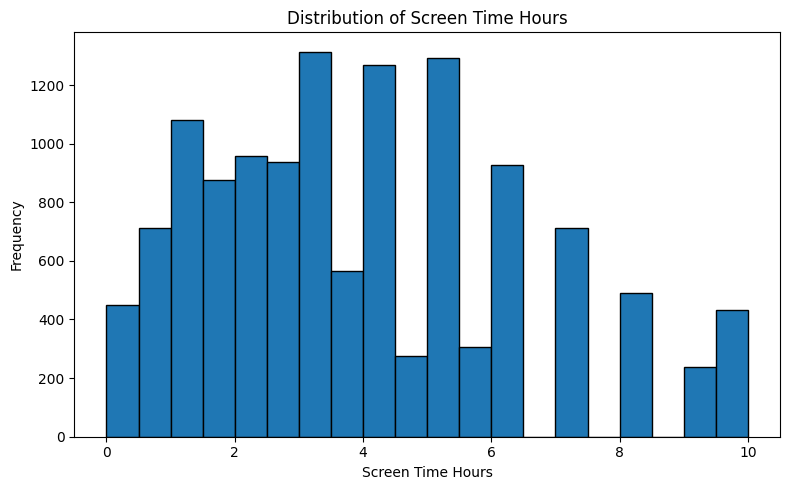

In [42]:
# Histogram of screen time
plt.figure(figsize=(8, 5))
plt.hist(clean_df["screen_time_hours"], bins=20, edgecolor="black")
plt.xlabel("Screen Time Hours")
plt.ylabel("Frequency")
plt.title("Distribution of Screen Time Hours")
plt.tight_layout()
plt.savefig(figures_dir / "screen_time_distribution.png", dpi=300)
plt.show()


**Interpretation:**  
Most students had approximately 1 to 6 hours of total screen time on an average school day. The distribution is not perfectly smooth because screen time was recoded from categorical responses into approximate numeric hours. Some students reported higher screen time, up to about 10 hours.

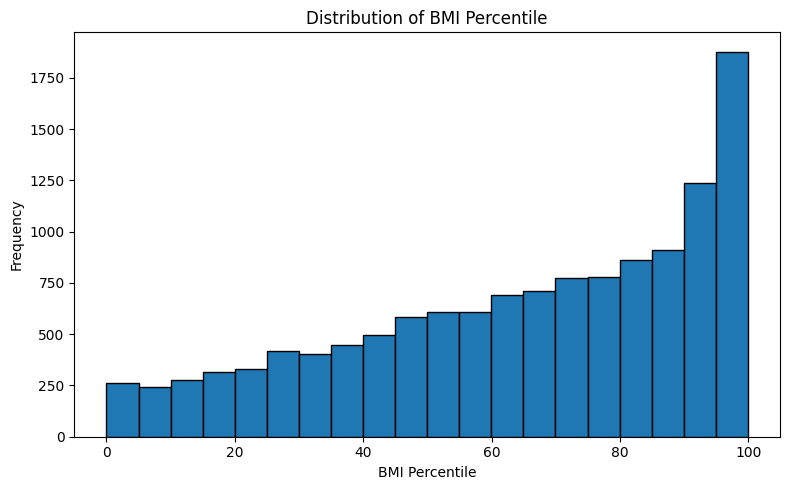

In [43]:
# Histogram of BMI percentile
plt.figure(figsize=(8, 5))
plt.hist(clean_df["bmi_percentile"], bins=20, edgecolor="black")
plt.xlabel("BMI Percentile")
plt.ylabel("Frequency")
plt.title("Distribution of BMI Percentile")
plt.tight_layout()
plt.savefig(figures_dir / "bmi_percentile_distribution.png", dpi=300)
plt.show()


**Interpretation:**  
BMI percentile ranged from 0 to 100. More observations appeared in the higher BMI percentile range, especially near 90 to 100. This suggests that many students in the cleaned dataset had relatively high BMI percentiles compared with students of the same age and sex.

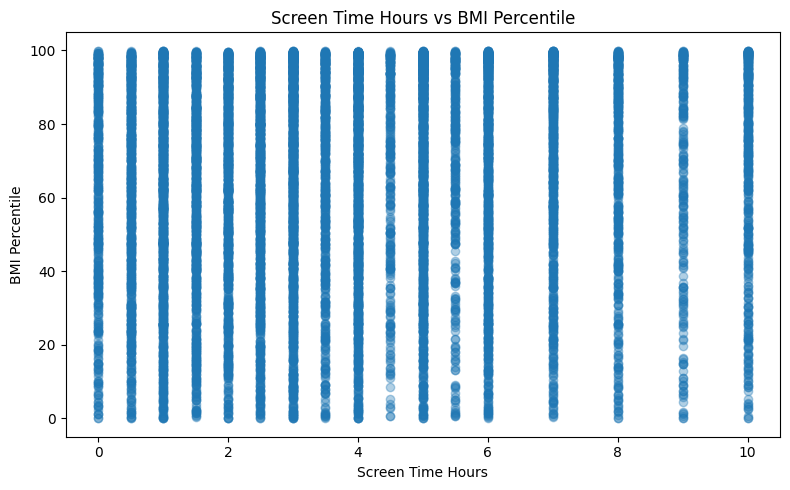

In [44]:
# Scatter plot for initial visual check
plt.figure(figsize=(8, 5))
plt.scatter(clean_df["screen_time_hours"], clean_df["bmi_percentile"], alpha=0.35)
plt.xlabel("Screen Time Hours")
plt.ylabel("BMI Percentile")
plt.title("Screen Time Hours vs BMI Percentile")
plt.tight_layout()
plt.savefig(figures_dir / "screen_time_vs_bmi_initial_scatter.png", dpi=300)
plt.show()


**Interpretation:**  
The scatter plot shows wide variation in BMI percentile at each screen time level. Students with both low and high screen time can have low or high BMI percentiles. A strong linear pattern is not visually obvious, so simple linear regression is needed to formally test the relationship.

## 9. Save cleaned dataset

The cleaned dataset will be used in the next notebook:

```text
02_main_regression.ipynb
```


In [45]:
# Save cleaned data
cleaned_data_path = processed_dir / "screen_time_bmi_cleaned.csv"
clean_df.to_csv(cleaned_data_path, index=False)

print("Cleaned dataset saved to:")
print(cleaned_data_path)

print("\nFinal variables:")
print(clean_df.columns.tolist())


Cleaned dataset saved to:
D:\作業\統計學實習\final individual project\data\processed\screen_time_bmi_cleaned.csv

Final variables:
['TelevisionWatching', 'ComputerUse', 'tv_hours', 'computer_hours', 'screen_time_hours', 'bmi_percentile']
